# Using mABCD (implemented in Julia) from a Python Notebook

Here we show how to use the Julia version of mABCD inside a Python notebook.
To call mABCD directly in Julia, for example via command line, please consult: https://github.com/KrainskiL/MLNABCDGraphGenerator.jl

The following needs to be installed:
* The Julia language: ```https://julialang.org/downloads/```
* PyJulia: ```pip install julia```

To install the mABCD Julia package, open Julia REPL (the command line interface) and enter:
```
using Pkg
Pkg.add(url="https://github.com/bkamins/ABCDGraphGenerator.jl", rev="v0.3")
Pkg.add(url="https://github.com/KrainskiL/MLNABCDGraphGenerator.jl")
```
This package requires Julia version 1.11 or later.


In [1]:
import julia               ## PyJulia, installed via: pip install julia
julia.install(quiet=True)  ## adding the path to the 'julia' executable may be needed
from julia.api import Julia 
jl = Julia(compiled_modules=False) ## needed on macOS (at least)
%load_ext julia.magic


Initializing Julia interpreter. This may take some time...


## Generate a small mABCD graph

In the folowing cell, the first line indicates that the cell contains Julia code.

Two files are required:
* config file, here ```default_config.toml```
* layer parameter file, here ```default_layer_params.csv``` 

Those files look as follows:

**default_config.toml**:
```
seed = "42"
n = "100"
edges_cor = ""
layer_params = "default_layer_params.csv"
```

**default_layer_params.csv**:
```
q,tau,r,gamma,delta,Delta,beta,s,S,xi
1,0,0.0,2.5,2,25,1.5,32,64,0.1
1,0,0.0,2.5,2,25,1.5,32,64,0.1
```

We generate the objects ```coms``` and ```edges_rewired```, the mABCD graph. In this case, all agents are active (q=1), no degrees-related (tau=0) and communities-related (r=0) correlations occur.


In [2]:
%%julia
using MLNABCDGraphGenerator

filename = "default_config.toml"
config = MLNABCDGraphGenerator.parse_config(filename)
active_nodes = MLNABCDGraphGenerator.generate_active_nodes(config)
degrees = MLNABCDGraphGenerator.generate_degrees(config, active_nodes, false)
com_sizes, coms = MLNABCDGraphGenerator.generate_communities(config, active_nodes)
edges = MLNABCDGraphGenerator.generate_abcd(config, degrees, com_sizes, coms)
edges = MLNABCDGraphGenerator.map_edges_to_agents(edges, active_nodes)
coms = MLNABCDGraphGenerator.map_communities_to_agents(config.n, coms, active_nodes);
edges_rewired = MLNABCDGraphGenerator.adjust_edges_correlation(config, edges, coms, active_nodes, false, false);


## Plot the above graph using Python

We build an ```igraph``` Graph object and plot it


In [3]:
from julia import Main as jl ## to get the Julia variables in Python code
import igraph as ig
import partition_igraph
import numpy as np
from collections import Counter 
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp


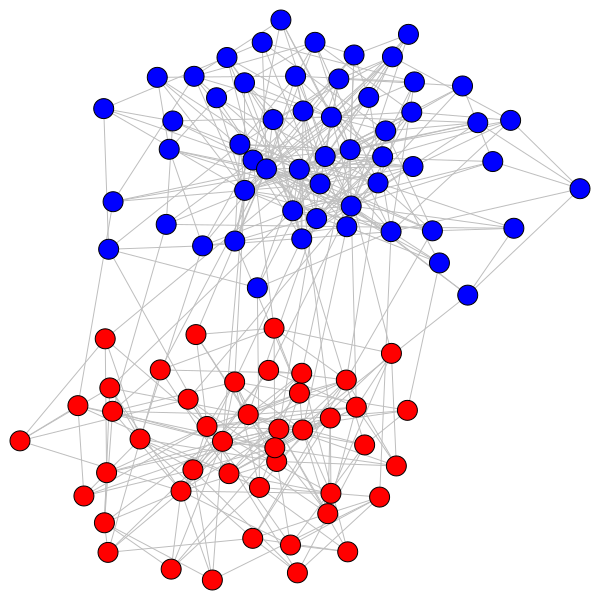

In [4]:
## get edge list and communities for layer 0
communities = jl.coms
edges = jl.edges_rewired

## plot
cls = ['red','blue','green']
g0 = ig.Graph.TupleList(list(edges[0]))
g0.vs['comm'] = [int(communities[0][i-1])-1 for i in g0.vs['name']] 
g0.vs['color'] = [cls[i] for i in g0.vs['comm']]
ly = g0.layout_fruchterman_reingold()
g0.vs['layout'] = ly
ig.plot(g0, layout=g0.vs['layout'], edge_color='grey')


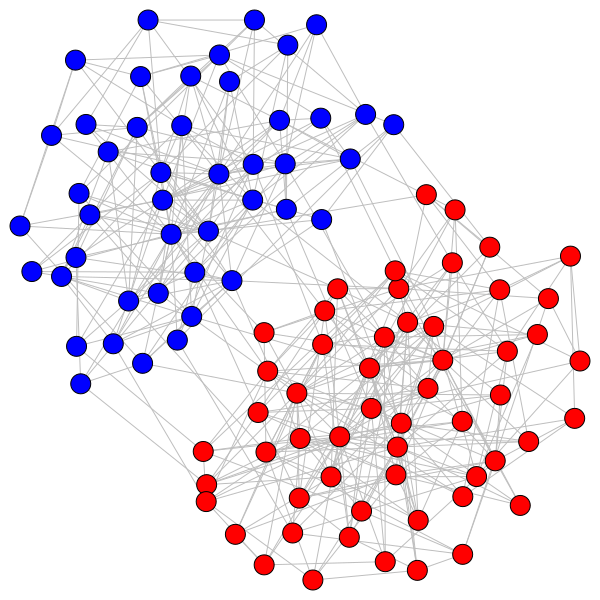

In [5]:
## now plot layer 1 
_dct = dict(zip(g0.vs['name'],g0.vs['layout']))
g1 = ig.Graph.TupleList(list(edges[1]))
g1.vs['comm'] = [int(communities[1][i-1])-1 for i in g1.vs['name']] 
g1.vs['color'] = [cls[i] for i in g1.vs['comm']]
g1.vs['layout'] = [_dct[v] for v in g1.vs['name']]
ig.plot(g1, edge_color='grey')


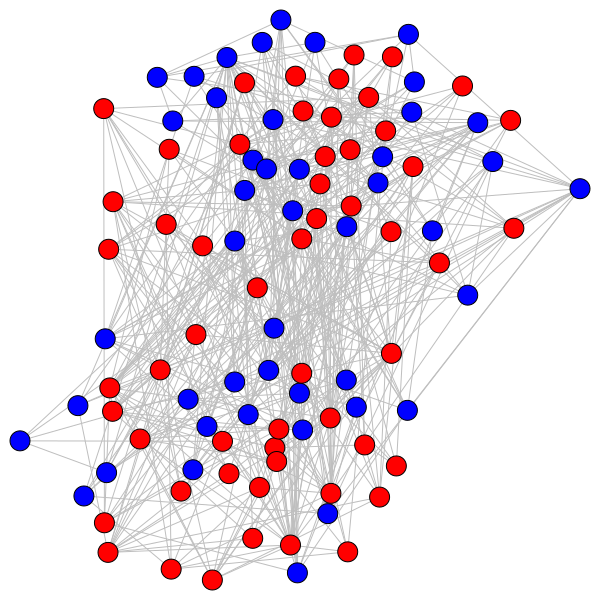

In [6]:
## now plot layer 1 using the same layout as layer 0
ig.plot(g1, layout=g1.vs['layout'], edge_color='grey')


## increase community related correlation

We do the same as above, but force community related correlation to some large value $r=0.9$.

Plotting layer 1 with the same layout as layer 0, we now observe strong correspondance between the communities.


In [7]:
%%julia

config.rs = [0.9,0.9] ## change community related correlation from 0 to 0.9
active_nodes = MLNABCDGraphGenerator.generate_active_nodes(config)
degrees = MLNABCDGraphGenerator.generate_degrees(config, active_nodes, false)
com_sizes, coms = MLNABCDGraphGenerator.generate_communities(config, active_nodes)
edges = MLNABCDGraphGenerator.generate_abcd(config, degrees, com_sizes, coms)
edges = MLNABCDGraphGenerator.map_edges_to_agents(edges, active_nodes)
coms = MLNABCDGraphGenerator.map_communities_to_agents(config.n, coms, active_nodes);
edges_rewired = MLNABCDGraphGenerator.adjust_edges_correlation(config, edges, coms, active_nodes, false, false);


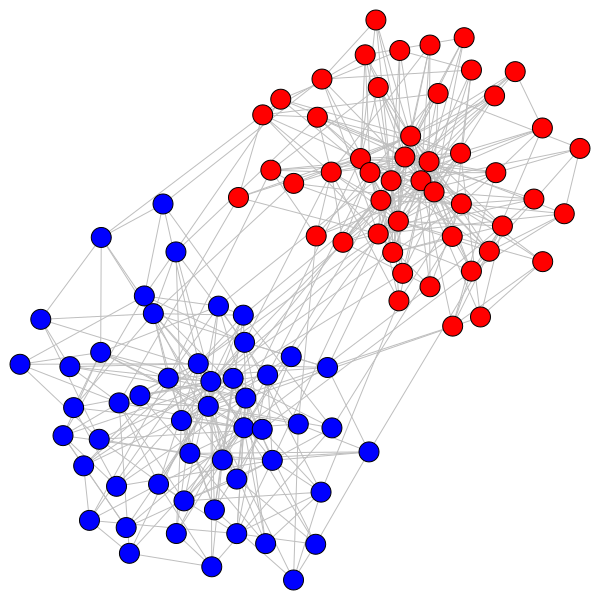

In [8]:
## get edge list and communities for layer 0
communities = jl.coms
edges = jl.edges_rewired

## build the first layer graphs and plot
g0 = ig.Graph.TupleList(list(edges[0]))
g0.vs['comm'] = [int(communities[0][i-1])-1 for i in g0.vs['name']] 
g0.vs['color'] = [cls[i] for i in g0.vs['comm']]
ly = g0.layout_fruchterman_reingold()
g0.vs['layout'] = ly
ig.plot(g0, layout=g0.vs['layout'], edge_color='grey')


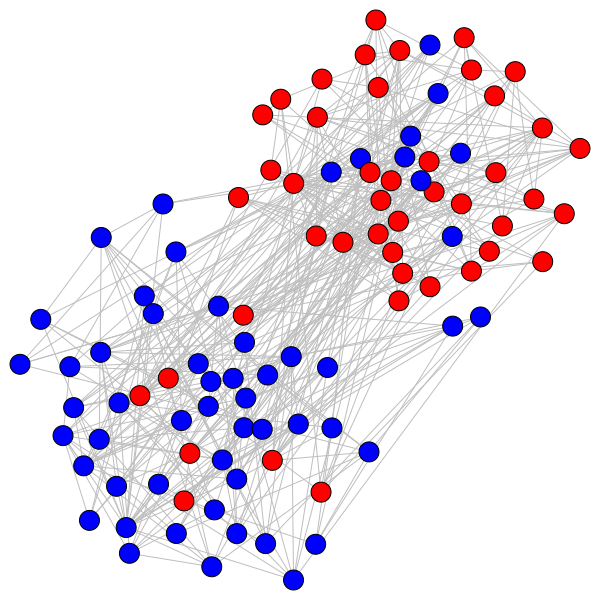

In [9]:
## now build and plot layer 1 using the same layout as layer 0
_dct = dict(zip(g0.vs['name'],g0.vs['layout']))
g1 = ig.Graph.TupleList(list(edges[1]))
g1.vs['comm'] = [int(communities[1][i-1])-1 for i in g1.vs['name']] 
g1.vs['color'] = [cls[i] for i in g1.vs['comm']]
g1.vs['layout'] = [_dct[v] for v in g1.vs['name']]
ig.plot(g1, layout=g1.vs['layout'], edge_color='grey')
